# Dataset EDA and preprocessing context

This notebook documents the dataset and preprocessing choices used in the MRI modality translation repository.

It covers:

- local dataset loading from the repo cache
- deterministic patient-level split summary
- representative T1/T2 slice pairs by view
- raw intensity distributions
- normalization context for the later global min-max vs percentile min-max ablation

This notebook is analysis-only. Core training and evaluation logic lives in `src/`, not in notebook cells.

In [1]:
from pathlib import Path
import json
import sys
import yaml

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("..").resolve()
if str(ROOT / "src") not in sys.path:
    sys.path.append(str(ROOT / "src"))

from mri_translation.data.download import load_local_dataset
from mri_translation.data.splits import load_split_manifest

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["image.cmap"] = "gray"

CONFIG_PATH = ROOT / "configs" / "resunet_global_minmax.yaml"

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

data_cfg = config["data"]
dataset_dir = ROOT / data_cfg["local_dataset_dir"]
split_dir = ROOT / data_cfg["split"]["split_dir"]

print("Repo root:", ROOT)
print("Dataset dir:", dataset_dir)
print("Split dir:", split_dir)

/home/dreadgator/mri-modality-translation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Repo root: /home/dreadgator/mri-modality-translation
Dataset dir: /home/dreadgator/mri-modality-translation/data/raw/mri_t1_t2_2d_sliced_64
Split dir: /home/dreadgator/mri-modality-translation/data/splits/default


In [2]:
full_ds = load_local_dataset(dataset_dir)
split_manifest = load_split_manifest(split_dir)

print("Total local samples:", len(full_ds))
print("Split keys:", split_manifest["splits"].keys())
print("Manifest summary:", split_manifest["summary"])

Total local samples: 155610
Split keys: dict_keys(['train', 'val', 'test'])
Manifest summary: {'num_total_samples': 155610, 'num_total_groups': 369, 'num_train_samples': 108360, 'num_val_samples': 22680, 'num_test_samples': 24570, 'num_train_groups': 258, 'num_val_groups': 55, 'num_test_groups': 56}


In [3]:
meta = full_ds.to_pandas()[["sample_id", "patient_id", "view", "source_split"]].copy()
meta.head()

,sample_id,patient_id,view,source_split
0,train_000000,083,axial,train
1,train_000001,083,axial,train
2,train_000002,083,axial,train
3,train_000003,083,axial,train
4,train_000004,083,axial,train


In [4]:
def split_dataframe(split_name: str) -> pd.DataFrame:
    ids = set(split_manifest["splits"][split_name])
    return meta[meta["sample_id"].isin(ids)].copy()

split_frames = {split: split_dataframe(split) for split in ["train", "val", "test"]}

summary_rows = []
for split, df in split_frames.items():
    row = {
        "split": split,
        "num_samples": len(df),
        "num_patients": df["patient_id"].nunique(),
    }
    view_counts = df["view"].value_counts().to_dict()
    for view_name in sorted(meta["view"].dropna().unique()):
        row[f"num_{view_name}"] = view_counts.get(view_name, 0)
    summary_rows.append(row)

split_summary_df = pd.DataFrame(summary_rows)
split_summary_df

,split,num_samples,num_patients,num_axial,num_coronal,num_sagittal
0,train,108360,258,25800,41280,41280
1,val,22680,55,5400,8640,8640
2,test,24570,56,5850,9360,9360


In [5]:
print(split_summary_df.to_markdown(index=False))
split_summary_df

tables_dir = ROOT / "reports" / "tables"
tables_dir.mkdir(parents=True, exist_ok=True)

split_summary_df.to_csv(tables_dir / "split_summary.csv", index=False)
(tables_dir / "split_summary.md").write_text(split_summary_df.to_markdown(index=False), encoding="utf-8")
print("Saved split summary table to", tables_dir)

| split   |   num_samples |   num_patients |   num_axial |   num_coronal |   num_sagittal |
|:--------|--------------:|---------------:|------------:|--------------:|---------------:|
| train   |        108360 |            258 |       25800 |         41280 |          41280 |
| val     |         22680 |             55 |        5400 |          8640 |           8640 |
| test    |         24570 |             56 |        5850 |          9360 |           9360 |
Saved split summary table to /home/dreadgator/mri-modality-translation/reports/tables


### Split summary interpretation

The split sizes are sensible and the view distribution remains well balanced across train, validation, and test.

Most importantly, the split is **patient-level**, not slice-level. That makes the held-out evaluation more defensible, because slices from the same patient are not shared across training and evaluation.

## Representative T1/T2 pairs by view

The dataset contains axial, coronal, and sagittal slices. The examples below display one representative paired T1/T2 slice for each view.

The plotting uses a **shared robust grayscale range per row** so the anatomy remains visible without misleading autoscaling.

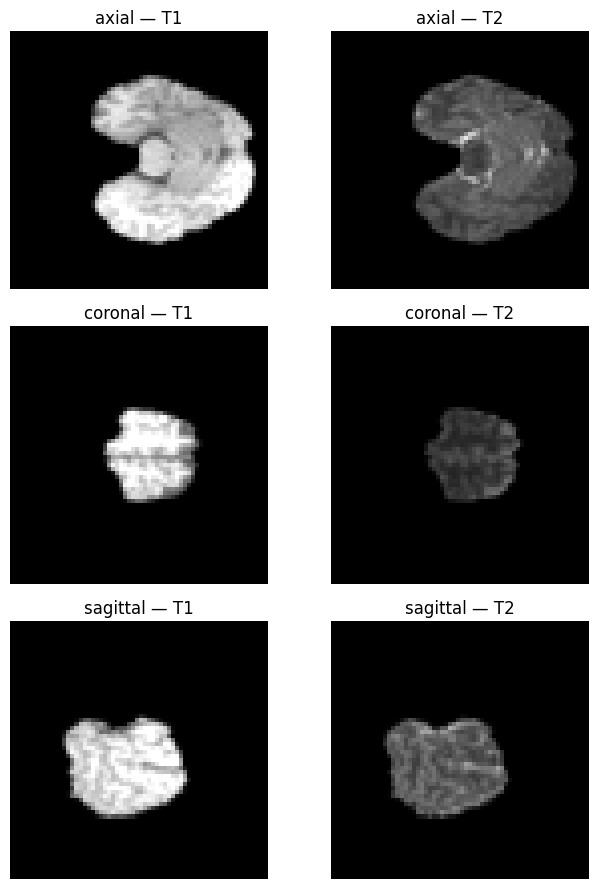

In [6]:
def robust_range(*arrays, lower=1.0, upper=99.0):
    stacked = np.concatenate([np.asarray(arr).reshape(-1) for arr in arrays])
    vmin = float(np.percentile(stacked, lower))
    vmax = float(np.percentile(stacked, upper))
    if vmax <= vmin:
        vmax = vmin + 1e-6
    return vmin, vmax

views = sorted(meta["view"].dropna().unique())
fig, axes = plt.subplots(len(views), 2, figsize=(7, 3 * len(views)))

if len(views) == 1:
    axes = np.expand_dims(axes, axis=0)

for i, view in enumerate(views):
    row_meta = meta[meta["view"] == view].iloc[0]
    sample = full_ds[int(row_meta.name)]

    t1 = np.asarray(sample["t1"], dtype=np.float32).squeeze()
    t2 = np.asarray(sample["t2"], dtype=np.float32).squeeze()

    vmin, vmax = robust_range(t1, t2)

    axes[i, 0].imshow(t1, vmin=vmin, vmax=vmax)
    axes[i, 0].set_title(f"{view} — T1")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(t2, vmin=vmin, vmax=vmax)
    axes[i, 1].set_title(f"{view} — T2")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [7]:
save_path = ROOT / "reports" / "figures" / "dataset_pairs_by_view.png"
save_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(save_path, dpi=200, bbox_inches="tight")
print("Saved:", save_path)

Saved: /home/dreadgator/mri-modality-translation/reports/figures/dataset_pairs_by_view.png


## Raw intensity distributions

The raw slice intensities are sampled from the training split to inspect their shape before normalization.

The main practical takeaway is that the distributions are skewed and contain large low-intensity regions, which later motivated the normalization ablation.

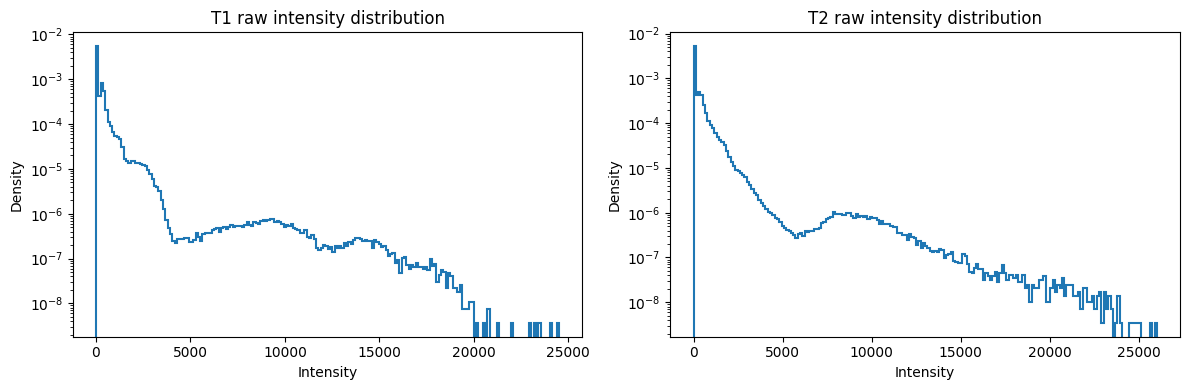

In [8]:
train_df = split_frames["train"].iloc[::200].copy()

t1_pixels = []
t2_pixels = []

for idx in train_df.index:
    sample = full_ds[int(idx)]
    t1_pixels.append(np.asarray(sample["t1"], dtype=np.float32).reshape(-1))
    t2_pixels.append(np.asarray(sample["t2"], dtype=np.float32).reshape(-1))

t1_pixels = np.concatenate(t1_pixels)
t2_pixels = np.concatenate(t2_pixels)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(t1_pixels, bins=200, density=True, histtype="step", linewidth=1.5)
ax[0].set_title("T1 raw intensity distribution")
ax[0].set_xlabel("Intensity")
ax[0].set_ylabel("Density")
ax[0].set_yscale("log")

ax[1].hist(t2_pixels, bins=200, density=True, histtype="step", linewidth=1.5)
ax[1].set_title("T2 raw intensity distribution")
ax[1].set_xlabel("Intensity")
ax[1].set_ylabel("Density")
ax[1].set_yscale("log")

plt.tight_layout()
plt.show()

In [9]:
save_path = ROOT / "reports" / "figures" / "raw_intensity_histograms.png"
save_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(save_path, dpi=200, bbox_inches="tight")
print("Saved:", save_path)

Saved: /home/dreadgator/mri-modality-translation/reports/figures/raw_intensity_histograms.png


## Normalization context

The repository tested two normalization schemes:

- global min-max
- percentile min-max

The code below estimates dataset-level statistics from a sampled subset of the training split and visualises how the same slice looks under each scheme.

The display ranges are chosen separately for each normalization view so that the visual comparison is readable. This is a **display choice**, not a change to the underlying normalization.

In [10]:
def estimate_stats(pixel_array: np.ndarray):
    return {
        "min": float(pixel_array.min()),
        "max": float(pixel_array.max()),
        "p1": float(np.percentile(pixel_array, 1.0)),
        "p99_5": float(np.percentile(pixel_array, 99.5)),
    }

t1_stats = estimate_stats(t1_pixels)
t2_stats = estimate_stats(t2_pixels)

stats_df = pd.DataFrame(
    [
        {"modality": "T1", **t1_stats},
        {"modality": "T2", **t2_stats},
    ]
)
stats_df

,modality,min,max,p1,p99_5
0,T1,0.0,24520.132812,0.0,3532.602051
1,T2,0.0,26029.000000,0.0,5053.065430


In [11]:
tables_dir = ROOT / "reports" / "tables"
tables_dir.mkdir(parents=True, exist_ok=True)

stats_df.to_csv(tables_dir / "normalization_stats.csv", index=False)
(tables_dir / "normalization_stats.md").write_text(stats_df.to_markdown(index=False), encoding="utf-8")
print("Saved normalization stats table to", tables_dir)

Saved normalization stats table to /home/dreadgator/mri-modality-translation/reports/tables


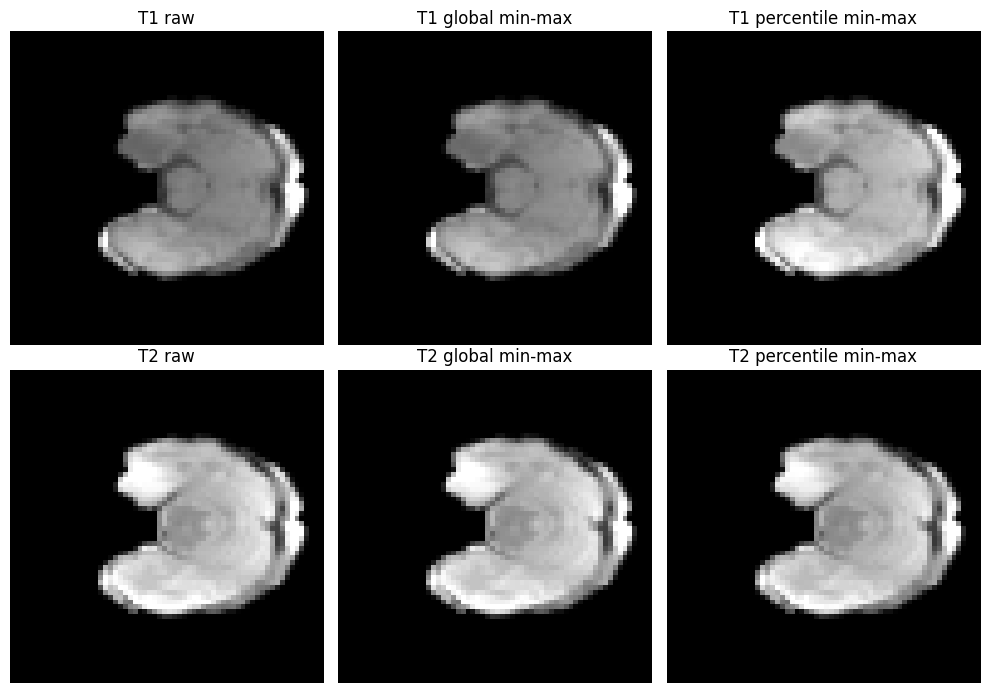

In [12]:
def normalize_global(arr: np.ndarray, min_val: float, max_val: float) -> np.ndarray:
    denom = max(max_val - min_val, 1e-8)
    return np.clip((arr - min_val) / denom, 0.0, 1.0)

def normalize_percentile(arr: np.ndarray, low: float, high: float) -> np.ndarray:
    denom = max(high - low, 1e-8)
    return np.clip((arr - low) / denom, 0.0, 1.0)

example_idx = int(split_frames["test"].iloc[0].name)
example = full_ds[example_idx]

t1 = np.asarray(example["t1"], dtype=np.float32).squeeze()
t2 = np.asarray(example["t2"], dtype=np.float32).squeeze()

t1_global = normalize_global(t1, t1_stats["min"], t1_stats["max"])
t1_percentile = normalize_percentile(t1, t1_stats["p1"], t1_stats["p99_5"])

t2_global = normalize_global(t2, t2_stats["min"], t2_stats["max"])
t2_percentile = normalize_percentile(t2, t2_stats["p1"], t2_stats["p99_5"])

fig, axes = plt.subplots(2, 3, figsize=(10, 7))

raw_vmin, raw_vmax = robust_range(t1, t2)
axes[0, 0].imshow(t1, vmin=raw_vmin, vmax=raw_vmax)
axes[0, 0].set_title("T1 raw")
axes[1, 0].imshow(t2, vmin=raw_vmin, vmax=raw_vmax)
axes[1, 0].set_title("T2 raw")

global_vmin, global_vmax = robust_range(t1_global, t2_global)
axes[0, 1].imshow(t1_global, vmin=global_vmin, vmax=global_vmax)
axes[0, 1].set_title("T1 global min-max")
axes[1, 1].imshow(t2_global, vmin=global_vmin, vmax=global_vmax)
axes[1, 1].set_title("T2 global min-max")

pct_vmin, pct_vmax = robust_range(t1_percentile, t2_percentile)
axes[0, 2].imshow(t1_percentile, vmin=pct_vmin, vmax=pct_vmax)
axes[0, 2].set_title("T1 percentile min-max")
axes[1, 2].imshow(t2_percentile, vmin=pct_vmin, vmax=pct_vmax)
axes[1, 2].set_title("T2 percentile min-max")

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Normalization interpretation

The visual appearance of the normalized slices depends strongly on how they are displayed.

Global min-max normalization often looks darker because the full intensity range is preserved and the anatomy occupies a relatively narrow low-intensity band. Percentile min-max can look more contrast-enhanced in isolated examples, but the later held-out experiments showed that it was a weaker and less stable preprocessing choice overall.

So this section is useful for understanding the data, but it is **not** itself evidence that percentile min-max is the better training normalization.

## EDA takeaways

- The repository uses a deterministic **patient-level split** rather than a slice-level random split.
- The task is paired **T1→T2 slice translation** on 64×64 single-channel images.
- The raw intensity distributions are highly skewed and include large low-intensity background regions.
- That motivated a normalization ablation later in the project.
- In the final held-out experiments, **global min-max** remained the stronger preprocessing choice overall.